All columns in FITS file:
['tns_name', 'previous_name', 'repeater_name', 'event_id', 'sub_num', 'ra', 'ra_err', 'dec', 'dec_err', 'ra_dec_notes', 'gl', 'gb', 'exp_up', 'exp_up_err', 'exp_low', 'exp_low_err', 'exp_notes', 'bonsai_snr', 'bonsai_dm', 'low_ft_68', 'up_ft_68', 'low_ft_95', 'up_ft_95', 'snr_fitb', 'dm_fitb', 'dm_fitb_err', 'dm_exc_ne2001', 'dm_exc_ymw16', 'bc_width', 'scat_time', 'scat_time_err', 'flux', 'flux_err', 'fluence', 'fluence_err', 'fluence_notes', 'fluence_win_extended', 'mjd_400', 'mjd_400_err', 'mjd_inf', 'mjd_inf_err', 'width_fitb', 'width_fitb_err', 'sp_idx', 'sp_idx_err', 'sp_run', 'sp_run_err', 'high_freq', 'low_freq', 'peak_freq', 'chi_sq', 'dof', 'flag_frac', 'notes_fitb', 'intrachan_flag', 'excluded_flag', 'sidelobe_flag', 'citizen_science_flag', 'catalog1_flag', 'catalog1_param_flag']

Detected key columns:
RA column: ra
Dec column: dec
DM column: dm_exc_ne2001
Repeater column: repeater_name

Removed 1199 duplicate repeater rows; remaining rows: 3846

Po

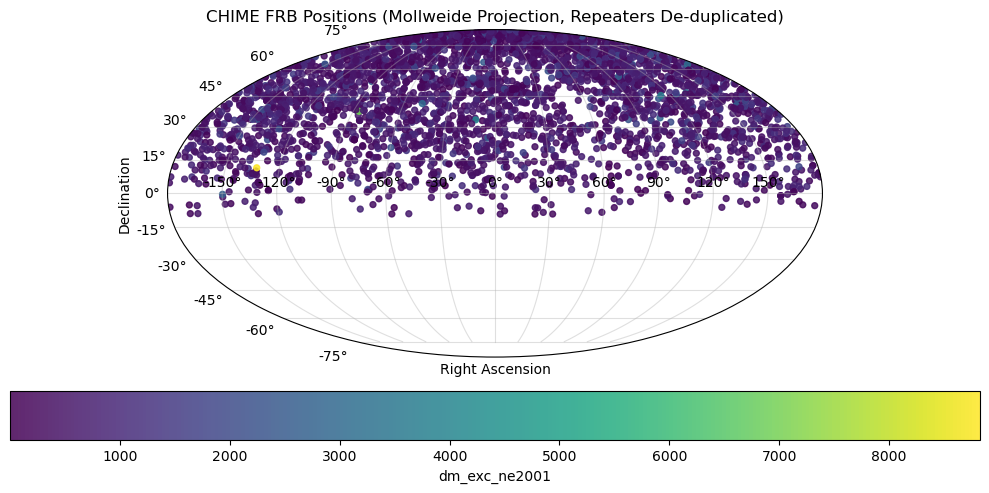

In [13]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

# Read CHIME FRB catalogue FITS file
fits_path = '/net/home/fohlen13/reischke/Git/pseudo_catcell_covariance_benchmark/data/chimefrbcat2.fits'
tab = Table.read(fits_path)

# Print all columns
print('All columns in FITS file:')
print(tab.colnames)

# Find likely position, DM, and repeater columns robustly
lower_to_actual = {c.lower(): c for c in tab.colnames}

def pick_col(candidates):
    for cand in candidates:
        if cand in lower_to_actual:
            return lower_to_actual[cand]
    return None

ra_col = pick_col(['ra', 'ra_deg', 'raj2000', 'raj'])
dec_col = pick_col(['dec', 'dec_deg', 'dej2000', 'decj'])
dm_col = pick_col(['dm', 'dm_exc_ne2001', 'dm_excess_ne2001', 'dm_obs'])
repeater_col = pick_col(['repeater_name', 'repeater', 'src_name', 'source_name'])

print('\nDetected key columns:')
print('RA column:', ra_col)
print('Dec column:', dec_col)
print('DM column:', dm_col)
print('Repeater column:', repeater_col)

# Keep each repeater only once (keep first occurrence)
if repeater_col is not None:
    def clean_repeater_name(value):
        if value is np.ma.masked:
            return ''
        name = str(value).strip()
        if name.lower() in {'', 'none', 'nan', '--'}:
            return ''
        return name

    seen_repeaters = set()
    keep_idx = []

    for i, val in enumerate(tab[repeater_col]):
        rep_name = clean_repeater_name(val)
        if rep_name == '':
            keep_idx.append(i)
        elif rep_name not in seen_repeaters:
            seen_repeaters.add(rep_name)
            keep_idx.append(i)

    n_before = len(tab)
    tab = tab[keep_idx]
    n_removed = n_before - len(tab)
    print(f'\nRemoved {n_removed} duplicate repeater rows; remaining rows: {len(tab)}')
else:
    print('\nNo repeater column found, so no repeater de-duplication was applied.')

# Print preview for position and DM
if ra_col is not None and dec_col is not None:
    print('\nPosition preview (first 10 rows):')
else:
    print('\nCould not detect both RA and Dec columns automatically.')

if dm_col is not None:
    print('\nDM preview (first 10 rows):')
    print(tab[dm_col][:10])
else:
    print('\nCould not detect a DM column automatically.')

# Mollweide plot (sky positions)
if ra_col is not None and dec_col is not None:
    ra = np.asarray(tab[ra_col], dtype=float)
    dec = np.asarray(tab[dec_col], dtype=float)

    # Convert RA from [0, 360] to [-180, 180] and then to radians for Mollweide
    ra_wrapped = np.remainder(ra + 360.0, 360.0)
    ra_wrapped[ra_wrapped > 180.0] -= 360.0

    lon = -np.radians(ra_wrapped)
    lat = np.radians(dec)

    # Color by DM if available
    if dm_col is not None:
        dm_vals = np.asarray(tab[dm_col], dtype=float)
        valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(dm_vals)
    else:
        valid = np.isfinite(lon) & np.isfinite(lat)

    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='mollweide')

    if dm_col is not None:
        sc = ax.scatter(lon[valid], lat[valid], c=dm_vals[valid], s=18, alpha=0.85, cmap='viridis')
        cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.08)
        cbar.set_label(dm_col)
    else:
        ax.scatter(lon[valid], lat[valid], s=18, alpha=0.85)

    ax.grid(True, alpha=0.4)
    ax.set_title('CHIME FRB Positions (Mollweide Projection, Repeaters De-duplicated)')
    ax.set_xlabel('Right Ascension')
    ax.set_ylabel('Declination')
    plt.tight_layout()
    plt.show()
else:
    print('\nSkipping Mollweide plot because RA/Dec columns were not both found.')

/tmp/ipykernel_3331933/1188557967.py:32: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  prob_map_smooth = hp.smoothing(prob_map, fwhm=fwhm_rad, verbose=False)


Probability mask: NSIDE=128, npix=196608
Mask stats: min=0.0000, max=1.0000, mean=0.2120
<p_det> at source positions = 0.5601


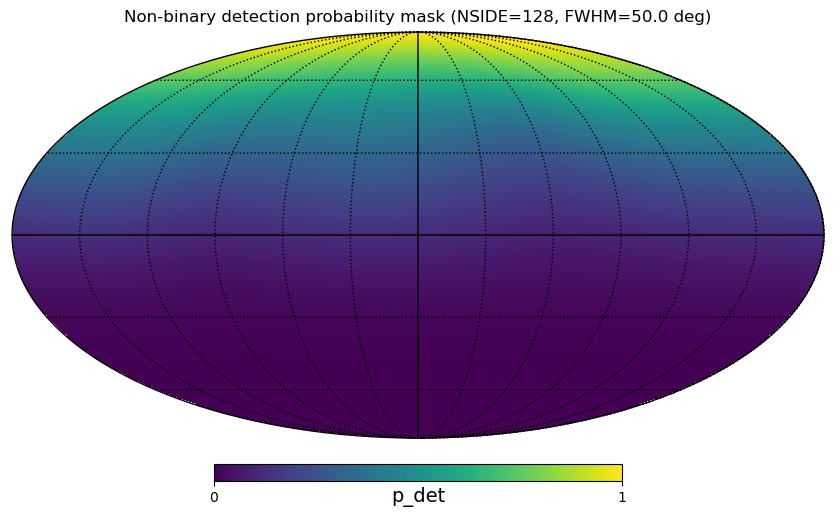

Saved non-binary probability mask to: /net/home/fohlen13/reischke/Git/pseudo_catcell_covariance_benchmark/output/chime/detection_probability_mask_nside128.fits


In [16]:
# Build a non-binary detection-probability mask from catalogue positions
import os
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Configuration for the probability mask
mask_nside = 128
smooth_fwhm_deg = 50

# Use the catalogue positions from Cell 1
if 'ra' not in globals() or 'dec' not in globals():
    raise RuntimeError("RA/Dec arrays not found. Run Cell 1 first.")

ra_arr = np.asarray(ra, dtype=float)
dec_arr = np.asarray(dec, dtype=float)
valid = np.isfinite(ra_arr) & np.isfinite(dec_arr)
ra_arr = ra_arr[valid]
dec_arr = dec_arr[valid]

npix = hp.nside2npix(mask_nside)
prob_map = np.zeros(npix, dtype=float)

# Put each source into a HEALPix pixel
theta = np.radians(90.0 - dec_arr)
phi = np.radians(np.mod(ra_arr, 360.0))
pix = hp.ang2pix(mask_nside, theta, phi)
np.add.at(prob_map, pix, 1.0)

# Smooth source density to get an average detection probability field
fwhm_rad = np.radians(smooth_fwhm_deg)
prob_map_smooth = hp.smoothing(prob_map, fwhm=fwhm_rad, verbose=False)

# Normalize to [0, 1] so this is a non-binary mask/probability map
if np.nanmax(prob_map_smooth) > 0:
    prob_mask = prob_map_smooth / np.nanmax(prob_map_smooth)
else:
    prob_mask = prob_map_smooth.copy()
prob_mask = np.clip(prob_mask, 0.0, 1.0)

print(f"Probability mask: NSIDE={mask_nside}, npix={npix}")
print(f"Mask stats: min={prob_mask.min():.4f}, max={prob_mask.max():.4f}, mean={prob_mask.mean():.4f}")

# Probability at catalogue positions (useful sanity check)
p_det_at_sources = hp.get_interp_val(prob_mask, theta, phi)
print(f"<p_det> at source positions = {np.mean(p_det_at_sources):.4f}")

# Plot the non-binary mask
hp.mollview(
    prob_mask,
    title=f"Non-binary detection probability mask (NSIDE={mask_nside}, FWHM={smooth_fwhm_deg:.1f} deg)",
    unit="p_det",
    min=0.0,
    max=1.0,
    cmap="viridis",
)
hp.graticule()
plt.show()

# Save the mask for later use
out_dir = os.path.join(os.path.dirname(os.path.dirname(fits_path)), "output", "chime")
os.makedirs(out_dir, exist_ok=True)
out_prob_mask = os.path.join(out_dir, f"detection_probability_mask_nside{mask_nside}.fits")
hp.write_map(out_prob_mask, prob_mask, overwrite=True, dtype=np.float32)
print(f"Saved non-binary probability mask to: {out_prob_mask}")

In [12]:
# Correct observed DM by subtracting the Milky Way DM contribution
if all(c in tab.colnames for c in ['dm_fitb', 'dm_exc_ne2001', 'dm_exc_ymw16']):
    dm_obs = np.asarray(tab['dm_fitb'], dtype=float)

    # MW DM inferred from each Galactic electron-density model
    dm_mw_ne2001 = dm_obs - np.asarray(tab['dm_exc_ne2001'], dtype=float)
    dm_mw_ymw16 = dm_obs - np.asarray(tab['dm_exc_ymw16'], dtype=float)

    # MW-corrected observed DM (= extragalactic DM estimate)
    dm_corr_ne2001 = dm_obs - dm_mw_ne2001
    dm_corr_ymw16 = dm_obs - dm_mw_ymw16

    tab['dm_corr_ne2001'] = dm_corr_ne2001
    tab['dm_corr_ymw16'] = dm_corr_ymw16

    print('Added MW-corrected DM columns: dm_corr_ne2001, dm_corr_ymw16')
    print('\nPreview (first 8 rows):')
    print(tab[['dm_fitb', 'dm_corr_ne2001', 'dm_corr_ymw16']][:8])
else:
    print('Missing one or more required columns: dm_fitb, dm_exc_ne2001, dm_exc_ymw16')

Added MW-corrected DM columns: dm_corr_ne2001, dm_corr_ymw16

Preview (first 8 rows):
     dm_fitb         dm_corr_ne2001     dm_corr_ymw16   
     pc / cm3                                           
------------------ ------------------ ------------------
 715.9129415697413  641.8104315605474    631.10781867973
 642.0138223770299  620.6921156337307   622.263449965856
109.60779528211837  78.74157883503162  86.79200658554264
317.31088576524843  223.3543460696999 198.82240668087906
 848.8783200451409  796.2228285195931  800.0211270652965
 656.0656678851907  550.5040483993365  519.9783465023615
 739.9004464711068  699.1679435341836   705.868813536668
 414.8922852341245 310.35325736936187 274.81356786130783


Created cubic dm_of_z on z in [0.010, 4.000]
Created cubic z_of_dm on DM in [0.000, 3408.901] pc/cm^3
Example: DM(z=1.0) = 937.469 pc/cm^3
Example: z(DM=1000) = 1.065


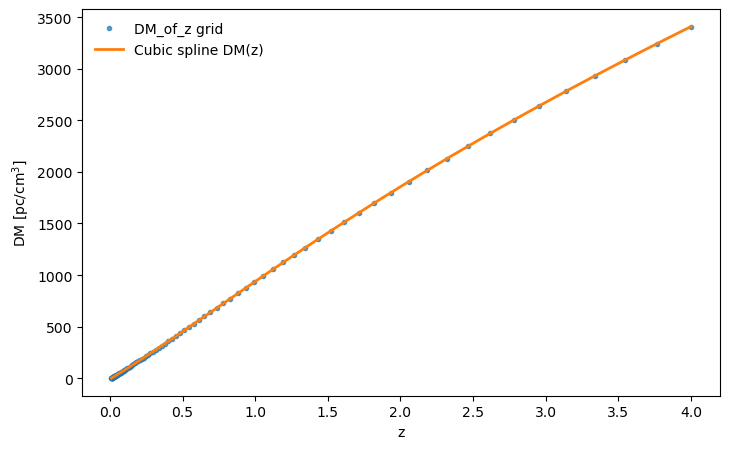

In [3]:
# Build splines DM(z) and inverse z(DM) from DM_of_z.npz
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline

dmz_path = '/Users/robert/Documents/Git/frb_catalogue/simulated_catalogues/data/DM_of_z.npz'
dmz = np.load(dmz_path)

z_grid = np.asarray(dmz['z'], dtype=float)
dm_grid = np.asarray(dmz['DM'], dtype=float)

valid = np.isfinite(z_grid) & np.isfinite(dm_grid)
z_grid = z_grid[valid]
dm_grid = dm_grid[valid]

# Forward spline DM(z): sort by z and remove duplicate z points
sort_idx_z = np.argsort(z_grid)
z_sorted = z_grid[sort_idx_z]
dm_sorted_by_z = dm_grid[sort_idx_z]
unique_z, unique_idx_z = np.unique(z_sorted, return_index=True)
unique_dm_for_dmofz = dm_sorted_by_z[unique_idx_z]

if len(unique_z) < 4:
    raise ValueError('Need at least 4 unique z points for a cubic DM(z) spline.')

dm_of_z = InterpolatedUnivariateSpline(unique_z, unique_dm_for_dmofz, k=3)

# Inverse spline z(DM): sort by DM and remove duplicate DM points
sort_idx_dm = np.argsort(dm_grid)
dm_sorted = dm_grid[sort_idx_dm]
z_sorted_by_dm = z_grid[sort_idx_dm]
unique_dm, unique_idx_dm = np.unique(dm_sorted, return_index=True)
unique_z_for_zofdm = z_sorted_by_dm[unique_idx_dm]

if len(unique_dm) < 4:
    raise ValueError('Need at least 4 unique DM points for a cubic z(DM) spline.')

z_of_dm = InterpolatedUnivariateSpline(unique_dm, unique_z_for_zofdm, k=3)

print(f'Created cubic dm_of_z on z in [{unique_z.min():.3f}, {unique_z.max():.3f}]')
print(f'Created cubic z_of_dm on DM in [{unique_dm.min():.3f}, {unique_dm.max():.3f}] pc/cm^3')
print(f'Example: DM(z=1.0) = {float(dm_of_z(1.0)):.3f} pc/cm^3')
print(f'Example: z(DM=1000) = {float(z_of_dm(1000.0)):.3f}')

z_plot = np.linspace(unique_z.min(), unique_z.max(), 400)
plt.figure(figsize=(7.4, 4.6))
plt.plot(unique_z, unique_dm_for_dmofz, 'o', ms=3, alpha=0.7, label='DM_of_z grid')
plt.plot(z_plot, dm_of_z(z_plot), '-', lw=2, label='Cubic spline DM(z)')
plt.xlabel('z')
plt.ylabel('DM [pc/cm$^3$]')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Using dm_corr_ne2001 mapped with precomputed z_of_dm spline (from Cell 3)
DM grid range used for mapping: [0.000, 3408.901] pc/cm^3
Valid mapped sources: 3768
z min/median/max = 0.0396 / 0.5537 / 3.6595
Bins used for PDF histogram: 60
Fitted lognormal parameters: shape=0.6484, scale=0.5363
Saved fitted n(z) to: /Users/robert/Documents/Git/frb_catalogue/simulated_catalogues/data/nz_fit_lognormal_dmz_spline.txt


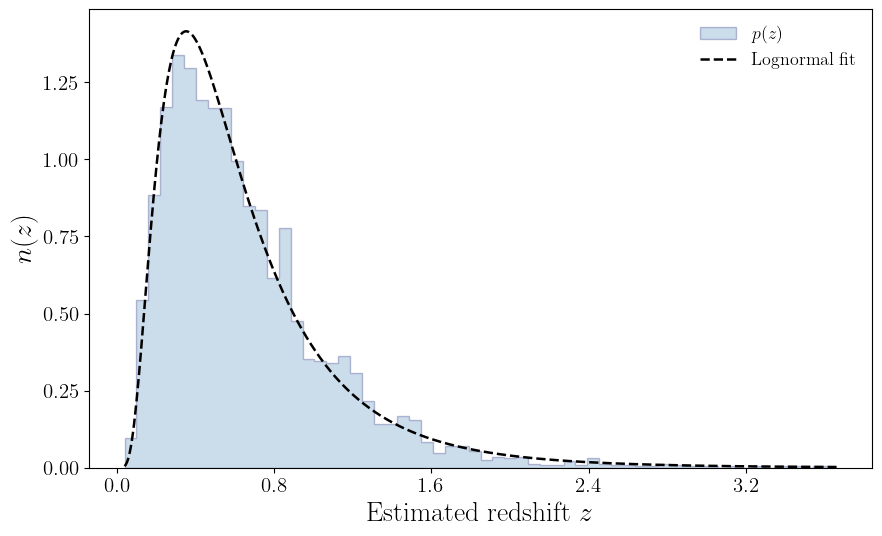

In [4]:
# Use z(DM) spline to construct n(z), fit a curve, and save n(z)
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import lognorm

# Build corrected DM explicitly if needed (robust to cell execution order)
if 'dm_corr_ne2001' not in tab.colnames:
    if all(c in tab.colnames for c in ['dm_fitb', 'dm_exc_ne2001']):
        dm_obs = np.asarray(tab['dm_fitb'], dtype=float)
        dm_mw_ne2001 = dm_obs - np.asarray(tab['dm_exc_ne2001'], dtype=float)
        tab['dm_corr_ne2001'] = dm_obs - dm_mw_ne2001
    else:
        raise ValueError('Missing required columns to build corrected DM (need dm_fitb and dm_exc_ne2001).')

dm_for_z = np.asarray(tab['dm_corr_ne2001'], dtype=float)

# Use z_of_dm spline created in Cell 3
if 'z_of_dm' not in globals() or 'unique_dm' not in globals():
    raise ValueError('z_of_dm spline not found. Run Cell 3 first to build DM(z) and z(DM) splines.')

dm_min, dm_max = float(np.min(unique_dm)), float(np.max(unique_dm))
valid_dm = np.isfinite(dm_for_z) & (dm_for_z >= dm_min) & (dm_for_z <= dm_max)
z_valid = z_of_dm(dm_for_z[valid_dm])
z_valid = z_valid[np.isfinite(z_valid) & (z_valid > 0)]

# Finer bins for redshift PDF (Freedman-Diaconis, clipped to a practical range)
q25, q75 = np.percentile(z_valid, [25, 75])
iqr = q75 - q25
if iqr > 0:
    bin_width = 2.0 * iqr / (len(z_valid) ** (1.0 / 3.0))
    n_bins = int(np.ceil((z_valid.max() - z_valid.min()) / bin_width)) if bin_width > 0 else 80
else:
    n_bins = 80
n_bins = int(np.clip(n_bins, 60, 140))

# Fit a lognormal distribution to positive redshifts
shape, loc, scale = lognorm.fit(z_valid, floc=0)
x = np.linspace(z_valid.min(), z_valid.max(), 600)
pdf_fit = lognorm.pdf(x, shape, loc=loc, scale=scale)

# Save fitted n(z) curve to file
out_dir = os.path.dirname(fits_path)
out_file = os.path.join(out_dir, 'nz_fit_lognormal_dmz_spline.txt')
header = (
    'n(z) fit from CHIME catalogue using precomputed z_of_dm spline\n'
    f'dm_file={dmz_path}\n'
    f'model=lognormal shape={shape:.8g} loc={loc:.8g} scale={scale:.8g}\n'
    'columns: z pdf_nz'
)
np.savetxt(out_file, np.column_stack([x, pdf_fit]), header=header, fmt='%.8e')

print('Using dm_corr_ne2001 mapped with precomputed z_of_dm spline (from Cell 3)')
print(f'DM grid range used for mapping: [{dm_min:.3f}, {dm_max:.3f}] pc/cm^3')
print(f'Valid mapped sources: {len(z_valid)}')
print(f'z min/median/max = {np.min(z_valid):.4f} / {np.median(z_valid):.4f} / {np.max(z_valid):.4f}')
print(f'Bins used for PDF histogram: {n_bins}')
print(f'Fitted lognormal parameters: shape={shape:.4f}, scale={scale:.4f}')
print(f'Saved fitted n(z) to: {out_file}')

# Plot style aligned with your template
fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

fig, ax = plt.subplots(1, 1, figsize=(9.0, 5.8))
ax.hist(
    z_valid,
    bins=n_bins,
    density=True,
    histtype='stepfilled',
    facecolor='steelblue',
    edgecolor='midnightblue',
    linewidth=1.0,
    alpha=0.28,
    label=r'$p(z)$'
)
ax.plot(x, pdf_fit, 'k--', lw=1.8, label=r'Lognormal fit')

ax.set_xlabel(r'Estimated redshift $z$', fontsize=fontsi2)
ax.set_ylabel(r'$n(z)$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.legend(fontsize=fontsi - 2, frameon=False, loc='upper right')
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.16, top=0.95)
plt.show()

NPZ keys: ['ell', 'cell']
Using key: cell
Shape: (130,), dtype: float64


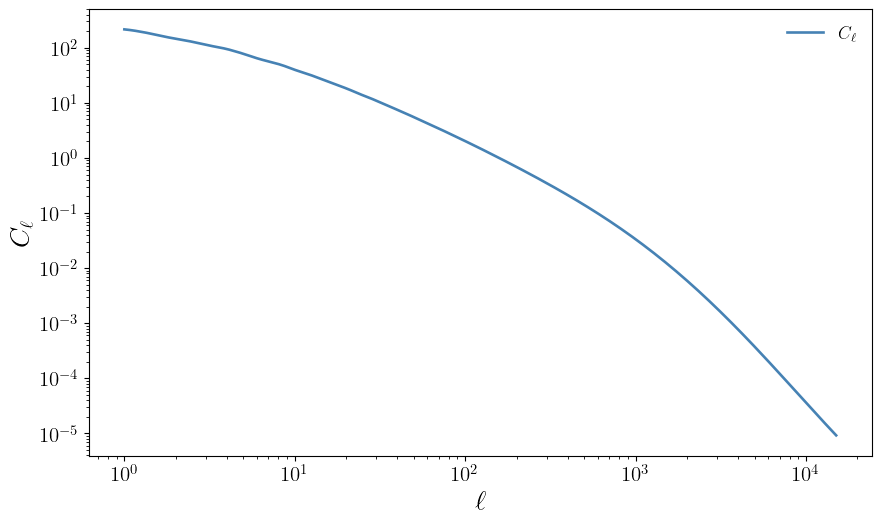

In [5]:
# Read cell data from npz and plot it with publication-style formatting
import numpy as np
import matplotlib.pyplot as plt
import shutil
from matplotlib.ticker import MaxNLocator

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

cell_path = '/Users/robert/Documents/Git/frb_catalogue/simulated_catalogues/data/cell_chime.npz'
cell_data = np.load(cell_path)

print('NPZ keys:', cell_data.files)
if len(cell_data.files) == 0:
    raise ValueError('No arrays found in cell_chime.npz')

# Prefer plotting the actual C_ell values if present
key = 'cell' if 'cell' in cell_data.files else cell_data.files[0]
arr = np.asarray(cell_data[key], dtype=float)

print(f"Using key: {key}")
print(f"Shape: {arr.shape}, dtype: {arr.dtype}")

fig, ax = plt.subplots(1, 1, figsize=(9.0, 5.8))

if arr.ndim == 1:
    if 'ell' in cell_data.files and key == 'cell':
        ell = np.asarray(cell_data['ell'], dtype=float)
        valid = np.isfinite(ell) & np.isfinite(arr) & (ell > 0) & (arr > 0)
        ell_plot = ell[valid]
        arr_plot = arr[valid]

        ax.plot(
            ell_plot,
            arr_plot,
            color='steelblue',
            lw=1.9,
            label=r'$C_\ell$'
        )
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$\ell$', fontsize=fontsi2)
    else:
        idx = np.arange(1, arr.size + 1, dtype=float)
        valid = np.isfinite(arr) & (arr > 0)
        ax.plot(idx[valid], arr[valid], color='steelblue', lw=1.9, label='cell')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Index', fontsize=fontsi2)

    ax.set_ylabel(r'$C_\ell$', fontsize=fontsi2)
    ax.legend(fontsize=fontsi - 2, frameon=False, loc='best')

elif arr.ndim == 2:
    im = ax.imshow(arr, aspect='auto', origin='lower', cmap='viridis')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r'$C_\ell$', fontsize=fontsi)
    ax.set_xlabel('Column index', fontsize=fontsi2)
    ax.set_ylabel('Row index', fontsize=fontsi2)

else:
    flat = arr.ravel()
    idx = np.arange(1, flat.size + 1, dtype=float)
    valid = np.isfinite(flat) & (flat > 0)
    ax.plot(idx[valid], flat[valid], color='steelblue', lw=1.5, label='flattened cell')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Flattened index', fontsize=fontsi2)
    ax.set_ylabel(r'$C_\ell$', fontsize=fontsi2)
    ax.legend(fontsize=fontsi - 2, frameon=False, loc='best')

ax.tick_params(labelsize=fontsi)
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.16, top=0.93)
plt.show()

Input C_ell points: 120 (unique: 106)
Using NSIDE=4096, lmax=12287
Spline ell range: [2, 15000]
Map npix=201326592, mean=-6.2194e-08, std=1.4721e+02


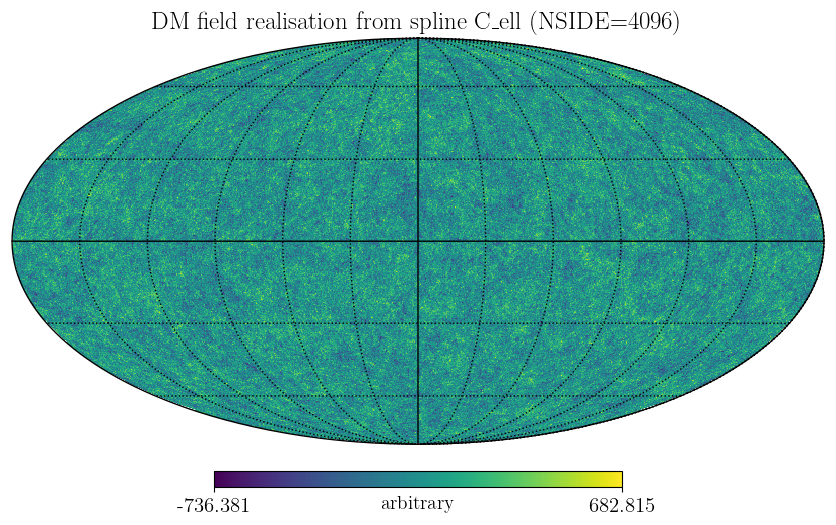

Saved map to: /Users/robert/Documents/Git/frb_catalogue/simulated_catalogues/output/chime/healpy_realisation_from_cell_nside4096.npy


In [ ]:
# Create a healpy scalar-field realization using a spline-evaluated C_ell
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline

cl_path = '/Users/robert/Documents/Git/frb_catalogue/simulated_catalogues/data/cell_chime.npz'
cl_npz = np.load(cl_path)

if not {'ell', 'cell'}.issubset(cl_npz.files):
    raise ValueError("cell_chime.npz must contain 'ell' and 'cell' arrays")

ell = np.asarray(cl_npz['ell'], dtype=int)
cl_in = np.asarray(cl_npz['cell'], dtype=float)

valid = np.isfinite(ell) & np.isfinite(cl_in) & (ell >= 2) & (cl_in > 0)
ell = ell[valid]
cl_in = cl_in[valid]

if ell.size < 4:
    raise ValueError('Need at least 4 valid C_ell points for a cubic spline.')

# Sort and remove duplicate ell values for stable spline construction
sort_idx = np.argsort(ell)
ell_sorted = ell[sort_idx]
cl_sorted = cl_in[sort_idx]
unique_ell, unique_idx = np.unique(ell_sorted, return_index=True)
unique_cl = cl_sorted[unique_idx]

if unique_ell.size < 4:
    raise ValueError('Need at least 4 unique ell points for a cubic spline.')

# Build a log-log spline to preserve positivity and smooth power-law behavior
cl_spline_log = InterpolatedUnivariateSpline(
    np.log(unique_ell.astype(float)),
    np.log(unique_cl),
    k=3
)

# Choose a practical NSIDE/lmax for synfast
nside = 4096
lmax_syn = min(int(np.max(unique_ell)), 3 * nside - 1)
ells_full = np.arange(lmax_syn + 1, dtype=float)

cl_full = np.zeros(lmax_syn + 1, dtype=float)
mask_eval = (ells_full >= max(2, unique_ell.min())) & (ells_full <= unique_ell.max())
cl_full[mask_eval] = np.exp(cl_spline_log(np.log(ells_full[mask_eval])))

# Safeguard low multipoles
cl_full[0] = 0.0
if lmax_syn >= 1:
    cl_full[1] = 0.0

# Keep non-negative in case of tiny numerical noise
cl_full = np.maximum(cl_full, 0.0)

seed = 42
np.random.seed(seed)
map_real = hp.synfast(cl_full, nside=nside, lmax=lmax_syn, new=True)

print(f'Input C_ell points: {len(cl_in)} (unique: {len(unique_ell)})')
print(f'Using NSIDE={nside}, lmax={lmax_syn}')
print(f'Spline ell range: [{int(unique_ell.min())}, {int(unique_ell.max())}]')
print(f'Map npix={map_real.size}, mean={np.mean(map_real):.4e}, std={np.std(map_real):.4e}')

hp.mollview(
    map_real,
    title=f'DM field realisation from spline C_ell (NSIDE={nside})',
    unit='arbitrary',
    cmap='viridis'
)
hp.graticule()
plt.show()

# Save map for later use under output/chime
output_dir = os.path.join(os.path.dirname(os.path.dirname(cl_path)), 'output', 'chime')
os.makedirs(output_dir, exist_ok=True)
out_map = os.path.join(output_dir, f'healpy_realisation_from_cell_nside{nside}.npy')
#np.save(out_map, map_real)
#print(f'Saved map to: {out_map}')

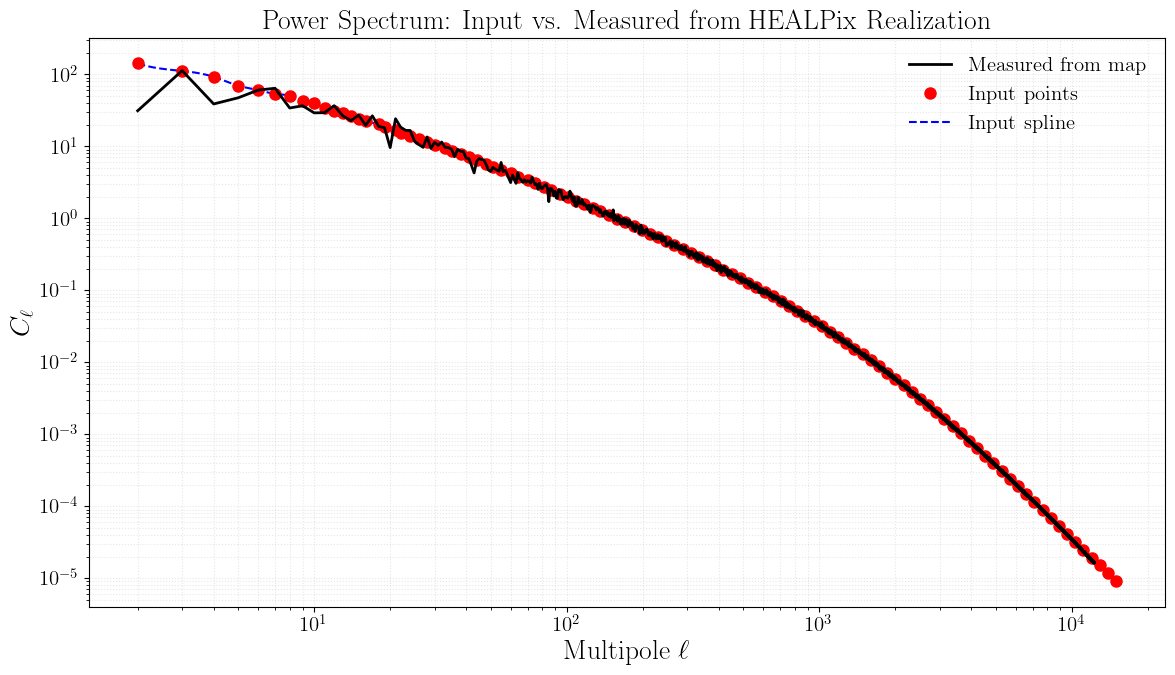

Overlap ell range: [2, 12287]
Relative difference (measured vs. input):
  Mean: 0.0240
  Median: 0.0157
  Max: 0.7800


In [8]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# Measure power spectrum from the generated healpy map
cl_measured = hp.anafast(map_real, lmax=lmax_syn)
ells_measured = np.arange(len(cl_measured))

# Create a comparison plot: input vs. measured C_ell
fig, ax = plt.subplots(figsize=(12, 7))

# Plot measured C_ell (from the map)
ax.loglog(ells_measured[2:], cl_measured[2:], 'k-', linewidth=2, label='Measured from map', zorder=5)

# Plot input C_ell points
ax.loglog(unique_ell, unique_cl, 'ro', markersize=8, label='Input points', zorder=4)

# Plot the input spline
ell_spline_eval = np.logspace(np.log10(unique_ell.min()), np.log10(unique_ell.max()), 300)
cl_spline_eval = np.exp(cl_spline_log(np.log(ell_spline_eval)))
ax.loglog(ell_spline_eval, cl_spline_eval, 'b--', linewidth=1.5, label='Input spline', zorder=3)

ax.set_xlabel(r'Multipole $\ell$', fontsize=fontsi2)
ax.set_ylabel(r'$C_\ell$', fontsize=fontsi2)
ax.set_title(r'Power Spectrum: Input vs. Measured from HEALPix Realization', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(fontsize=fontsi, frameon=False)
ax.grid(True, alpha=0.3, which='both', linestyle=':')

plt.tight_layout()
plt.show()

# Compute relative difference in the overlap region
ell_min = max(2, int(unique_ell.min()))
ell_max = min(lmax_syn, int(unique_ell.max()))
ell_overlap = (ells_measured >= ell_min) & (ells_measured <= ell_max)

cl_meas_overlap = cl_measured[ell_overlap]
cl_input_overlap = cl_full[ell_overlap]
cl_input_overlap = cl_input_overlap[cl_input_overlap > 0]  # avoid division by zero

if len(cl_meas_overlap) > 0 and len(cl_input_overlap) > 0:
    relative_diff = np.abs(cl_meas_overlap[:len(cl_input_overlap)] - cl_input_overlap) / cl_input_overlap
    print(f'Overlap ell range: [{ell_min}, {ell_max}]')
    print(f'Relative difference (measured vs. input):')
    print(f'  Mean: {np.mean(relative_diff):.4f}')
    print(f'  Median: {np.median(relative_diff):.4f}')
    print(f'  Max: {np.max(relative_diff):.4f}')
else:
    print('Warning: No overlap region for comparison')

In [64]:
import numpy as np
import healpy as hp
from astropy.table import Table
from astropy.io import fits
import os

# ============================================================================
# Parameters: configure additive noise moments (shared by both noise models)
# ============================================================================
noise_mean = 50.0          # Mean of additive noise
noise_variance = 50.0**2   # Variance (sigma^2) of additive noise
noise_type = 'gaussian+log-normal'

# ============================================================================
# Evaluate map at catalogue positions
# ============================================================================
ra_for_healpy = np.where(ra < 0, ra + 360.0, ra)
dec_for_healpy = dec.copy()

theta_raw = np.radians(90.0 - dec_for_healpy)
phi = np.radians(ra_for_healpy)

valid_coords = np.isfinite(theta_raw) & np.isfinite(phi)
theta = np.full_like(theta_raw, np.nan)
theta[valid_coords] = np.clip(theta_raw[valid_coords], 1e-6, np.pi - 1e-6)

map_values = np.full(len(theta), np.nan)
if np.any(valid_coords):
    map_values[valid_coords] = hp.get_interp_val(map_real, theta[valid_coords], phi[valid_coords])

print(f'Evaluated map at {len(map_values)} catalogue positions')
print(f'Number of NaN values: {np.isnan(map_values).sum()}')
print(f'Map values (no noise): min={np.nanmin(map_values):.4e}, max={np.nanmax(map_values):.4e}, mean={np.nanmean(map_values):.4e}')

# ============================================================================
# Build two additive noise realisations with the same target mean/variance
# ============================================================================
rng = np.random.default_rng(42)

# Gaussian additive noise
noise_gaussian = rng.normal(loc=noise_mean, scale=np.sqrt(noise_variance), size=len(map_values))
map_values_with_gaussian_noise = map_values + noise_gaussian

# Log-normal additive noise with matched mean/variance
if noise_mean <= 0:
    raise ValueError('Log-normal additive noise requires noise_mean > 0.')
s_sq = np.log(1.0 + noise_variance / (noise_mean ** 2))
s = np.sqrt(s_sq)
m = np.log(noise_mean) - 0.5 * s_sq
noise_lognormal = rng.lognormal(mean=m, sigma=s, size=len(map_values))
map_values_with_lognormal_noise = map_values + noise_lognormal

print(f'\nGaussian noise: mean={np.nanmean(noise_gaussian):.4e}, var={np.nanvar(noise_gaussian):.4e}')
print(f'Log-normal params: m={m:.6f}, s={s:.6f}')
print(f'Log-normal noise: mean={np.nanmean(noise_lognormal):.4e}, var={np.nanvar(noise_lognormal):.4e}')
print(f'Map + Gaussian: min={np.nanmin(map_values_with_gaussian_noise):.4e}, max={np.nanmax(map_values_with_gaussian_noise):.4e}, mean={np.nanmean(map_values_with_gaussian_noise):.4e}')
print(f'Map + Log-normal: min={np.nanmin(map_values_with_lognormal_noise):.4e}, max={np.nanmax(map_values_with_lognormal_noise):.4e}, mean={np.nanmean(map_values_with_lognormal_noise):.4e}')

# Keep backward-compatible variable for downstream plotting cell
map_values_with_noise = map_values_with_gaussian_noise

# ============================================================================
# Build output catalogue from generated values only
# ============================================================================
output_cat = Table()
output_cat['RA'] = np.asarray(ra_for_healpy, dtype=float)
output_cat['Dec'] = np.asarray(dec_for_healpy, dtype=float)
output_cat['DM'] = map_values
output_cat['DM_with_gaussian_noise'] = map_values_with_gaussian_noise
output_cat['DM_with_lognormal_noise'] = map_values_with_lognormal_noise

# FITS units metadata
output_cat['RA'].unit = 'deg'
output_cat['Dec'].unit = 'deg'
output_cat['DM'].unit = 'pc / cm3'
output_cat['DM_with_gaussian_noise'].unit = 'pc / cm3'
output_cat['DM_with_lognormal_noise'].unit = 'pc / cm3'

if 'z_valid' in globals() and len(z_valid) == len(map_values):
    output_cat['Redshift_generated'] = z_valid
    output_cat['Redshift_generated'].unit = '1'

print(f'\nOutput catalogue shape: {len(output_cat)} sources × {len(output_cat.colnames)} columns')
print(f'Columns: {", ".join(output_cat.colnames)}')
print('Units:')
for cname in output_cat.colnames:
    print(f'  {cname}: {output_cat[cname].unit}')

# ============================================================================
# Save catalogue with interpolated C_ell (the exact one passed to healpy)
# ============================================================================
out_dir = os.path.join(os.path.dirname(os.path.dirname(fits_path)), 'output', 'chime')
os.makedirs(out_dir, exist_ok=True)
catalogue_name = f'chime_catalogue_nside{nside}_noise.fits'
out_path = os.path.join(out_dir, catalogue_name)

# Main catalogue table HDU
catalog_hdu = fits.BinTableHDU(output_cat, name='CATALOG')
catalog_hdu.header['NOISEMDL'] = noise_type
catalog_hdu.header['NOMEAN'] = float(noise_mean)
catalog_hdu.header['NOVAR'] = float(noise_variance)

# Interpolated C_ell used directly by hp.synfast (ell = 0..lmax_syn)
ell_full = np.arange(len(cl_full), dtype=np.int32)
cl_interp_table = Table()
cl_interp_table['ell'] = ell_full
cl_interp_table['cell'] = np.asarray(cl_full, dtype=np.float64)
cl_interp_table['ell'].unit = '1'
cl_interp_table['cell'].unit = '1'
cl_interp_hdu = fits.BinTableHDU(cl_interp_table, name='Cell')
cl_interp_hdu.header['DESC'] = 'C_ell passed to hp.synfast'
cl_interp_hdu.header['NSIDE'] = int(nside)
cl_interp_hdu.header['LMAXMAP'] = int(lmax_syn)

# Write full FITS file
hdul = fits.HDUList([fits.PrimaryHDU(), catalog_hdu, cl_interp_hdu])
hdul.writeto(out_path, overwrite=True)
print(f'\nSaved catalogue to: {out_path}')
print('Added FITS extensions: CATALOG, CL_INTERP')

Evaluated map at 3846 catalogue positions
Number of NaN values: 27
Map values (no noise): min=-5.0310e+02, max=6.0117e+02, mean=-7.9435e-01

Gaussian noise: mean=4.9330e+01, var=2.4941e+03
Log-normal params: m=3.565449, s=0.832555
Log-normal noise: mean=5.0189e+01, var=2.5742e+03
Map + Gaussian: min=-4.4723e+02, max=6.1608e+02, mean=4.8434e+01
Map + Log-normal: min=-4.7617e+02, max=8.6891e+02, mean=4.9464e+01

Output catalogue shape: 3846 sources × 5 columns
Columns: RA, Dec, DM, DM_with_gaussian_noise, DM_with_lognormal_noise
Units:
  RA: deg
  Dec: deg
  DM: pc / cm3
  DM_with_gaussian_noise: pc / cm3
  DM_with_lognormal_noise: pc / cm3

Saved catalogue to: /Users/robert/Documents/Git/frb_catalogue/simulated_catalogues/output/chime/chime_catalogue_nside4096_noise.fits
Added FITS extensions: CATALOG, CL_INTERP


In [61]:
# Diagnostic: Check what's happening with the map values
print('=== Diagnostic Info ===')
print(f'Original map_real[0:10]: {map_real[0:10]}')
print(f'Catalogue columns: {tab.colnames}')
print(f'RA shape: {ra.shape}, Dec shape: {dec.shape}')
print(f'ra_for_healpy[0:5]: {ra_for_healpy[0:5]}')
print(f'dec_for_healpy[0:5]: {dec_for_healpy[0:5]}')
print(f'theta[0:5]: {theta[0:5]}')
print(f'phi[0:5]: {phi[0:5]}')
print(f'map_values type: {type(map_values)}, shape: {map_values.shape}')
print(f'map_values[0:10]: {map_values[0:10]}')
print(f'Number of NaNs: {np.isnan(map_values).sum()}')

=== Diagnostic Info ===
Original map_real[0:10]: [ 97.14300707 179.72312897  61.91824821  27.37357579  41.19176225
 186.60590745 246.49530793 231.45607444 133.53382073  90.2212564 ]
Catalogue columns: ['tns_name', 'previous_name', 'repeater_name', 'event_id', 'sub_num', 'ra', 'ra_err', 'dec', 'dec_err', 'ra_dec_notes', 'gl', 'gb', 'exp_up', 'exp_up_err', 'exp_low', 'exp_low_err', 'exp_notes', 'bonsai_snr', 'bonsai_dm', 'low_ft_68', 'up_ft_68', 'low_ft_95', 'up_ft_95', 'snr_fitb', 'dm_fitb', 'dm_fitb_err', 'dm_exc_ne2001', 'dm_exc_ymw16', 'bc_width', 'scat_time', 'scat_time_err', 'flux', 'flux_err', 'fluence', 'fluence_err', 'fluence_notes', 'fluence_win_extended', 'mjd_400', 'mjd_400_err', 'mjd_inf', 'mjd_inf_err', 'width_fitb', 'width_fitb_err', 'sp_idx', 'sp_idx_err', 'sp_run', 'sp_run_err', 'high_freq', 'low_freq', 'peak_freq', 'chi_sq', 'dof', 'flag_frac', 'notes_fitb', 'intrachan_flag', 'excluded_flag', 'sidelobe_flag', 'citizen_science_flag', 'catalog1_flag', 'catalog1_param_flag

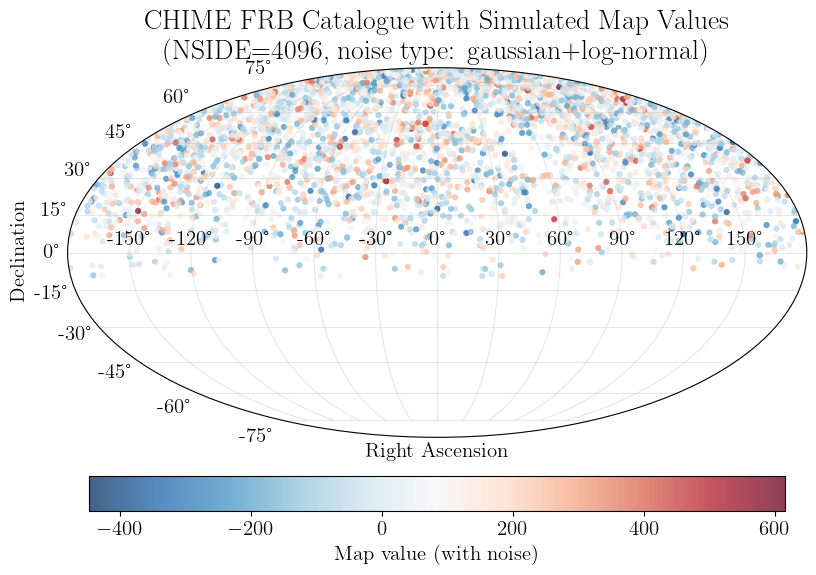


Catalogue plot complete:
  Valid sources plotted: 3819 / 3846
  Catalogue saved as: chime_catalogue_nside4096_noise.fits


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import shutil

# Plot the catalogue: map values at CHIME positions
fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

# Prepare positions for Mollweide plot
ra_wrapped = np.remainder(ra + 360.0, 360.0)
ra_wrapped[ra_wrapped > 180.0] -= 360.0
lon = -np.radians(ra_wrapped)
lat = np.radians(dec)

# Create Mollweide plot with map values as colors
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Plot with map values (with noise) as color
valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(map_values_with_noise)
sc = ax.scatter(
    lon[valid], 
    lat[valid], 
    c=map_values_with_noise[valid], 
    s=20, 
    alpha=0.75, 
    cmap='RdBu_r',
    edgecolors='none'
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.08, shrink=0.8)
cbar.set_label(r'Map value (with noise)', fontsize=fontsi)

ax.grid(True, alpha=0.3)
ax.set_title(
    f'CHIME FRB Catalogue with Simulated Map Values\n'
    f'(NSIDE={nside}, noise type: {noise_type})',
    fontsize=fontsi2
)
ax.set_xlabel('Right Ascension', fontsize=fontsi)
ax.set_ylabel('Declination', fontsize=fontsi)

fig.subplots_adjust(left=0.08, right=0.95, bottom=0.12, top=0.92)
plt.show()

print(f'\nCatalogue plot complete:')
print(f'  Valid sources plotted: {valid.sum()} / {len(valid)}')
print(f'  Catalogue saved as: {catalogue_name}')

In [69]:
# Print catalogue columns/units and verify interpolated C_ell extension
from astropy.table import Table
from astropy.io import fits

saved_cat = Table.read(out_path)
print('Saved catalogue path:', out_path)
print('Header names (columns):')
for name in saved_cat.colnames:
    print(name)

print('\nUnits:')
for name in saved_cat.colnames:
    print(f'{name}: {saved_cat[name].unit}')

with fits.open(out_path) as hdul:
    print('\nFITS extensions:')
    for i, hdu in enumerate(hdul):
        print(i, hdu.name)

    if 'Cell' in hdul:
        cl_interp = hdul['Cell'].data
        hdr = hdul['Cell'].header
        print('NSIDE:', hdr.get('NSIDE'))
        print('LMAXMAP:', hdr.get('LMAXMAP'))
        print('Number of rows:', len(cl_interp))

Saved catalogue path: /Users/robert/Documents/Git/frb_catalogue/simulated_catalogues/output/chime/chime_catalogue_nside4096_noise.fits
Header names (columns):
RA
Dec
DM
DM_with_gaussian_noise
DM_with_lognormal_noise

Units:
RA: deg
Dec: deg
DM: pc / cm3
DM_with_gaussian_noise: pc / cm3
DM_with_lognormal_noise: pc / cm3

FITS extensions:
0 PRIMARY
1 CATALOG
2 CELL
NSIDE: 4096
LMAXMAP: 12287
Number of rows: 12288
